In [32]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier,AdaBoostClassifier,GradientBoostingClassifier,StackingClassifier
from sklearn.svm import SVC

SEED=42


In [33]:
#Load data and split

data=load_breast_cancer(as_frame=True)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=SEED,stratify=y)

X_train.shape,X_test.shape,y_train.mean(),y_test.mean()


((426, 30),
 (143, 30),
 np.float64(0.6267605633802817),
 np.float64(0.6293706293706294))

In [34]:
# A simple baseline model

baseline=Pipeline([
    ('scaler',StandardScaler()),
    ('clf',LogisticRegression(max_iter=5000,random_state=SEED))
])
baseline.fit(X_train,y_train)
class_1_prob=baseline.predict_proba(X_test)[:,1]
y_pred=(class_1_prob>0.5).astype(int)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("AUC:",roc_auc_score(y_test,class_1_prob))
print("/n Confusion Matrix",confusion_matrix(y_test,y_pred))
print("/n Classification Report",classification_report(y_test,y_pred))

Accuracy: 0.986013986013986
AUC: 0.9976939203354298
/n Confusion Matrix [[52  1]
 [ 1 89]]
/n Classification Report               precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [35]:
# Bagging Classifier
base_tree=DecisionTreeClassifier(random_state=SEED)

bagging=BaggingClassifier(estimator=base_tree,
                          n_estimators=100, # 10,50,200,500
                          random_state=SEED,
                          bootstrap=True,
                          n_jobs=-1)

bagging.fit(X_train,y_train)
class_1_prob=bagging.predict_proba(X_test)[:,1]
y_pred=(class_1_prob>0.5).astype(int)

print("Bagging Accuracy:",accuracy_score(y_test,y_pred))
print("Bagging AUC:",roc_auc_score(y_test,class_1_prob))

Bagging Accuracy: 0.951048951048951
Bagging AUC: 0.9927672955974842


In [36]:
# Random Forset
rf=RandomForestClassifier(n_estimators=300,
                          random_state=SEED,
                          n_jobs=-1)

rf.fit(X_train,y_train)
p_rf=rf.predict_proba(X_test)[:,1]
y_pred=(p_rf>0.5).astype(int)

print("Random Forest Accuracy:",accuracy_score(y_test,y_pred))
print("Random Forest AUC:",roc_auc_score(y_test,p_rf))

Random Forest Accuracy: 0.958041958041958
Random Forest AUC: 0.9948637316561845


In [37]:
# Boosting
stump = DecisionTreeClassifier(max_depth=1, random_state=SEED)

adaboost=AdaBoostClassifier(
    estimator=stump,
    n_estimators=200,
    learning_rate=0.5, # 0.1,0.5,1.0
    random_state=SEED
)


adaboost.fit(X_train,y_train)
p_ada=adaboost.predict_proba(X_test)[:,1]
y_pred=(p_ada>0.5).astype(int)

print("AdaBoost Accuracy:",accuracy_score(y_test,y_pred))
print("AdaBoost AUC:",roc_auc_score(y_test,p_ada))

AdaBoost Accuracy: 0.958041958041958
AdaBoost AUC: 0.9878406708595389


In [38]:
#Gradient Boosting

gb=GradientBoostingClassifier(random_state=SEED)
gb.fit(X_train,y_train)
p_gb=gb.predict_proba(X_test)[:,1]
y_pred=(p_gb>=0.5).astype(int)

print("Gradient Boosting Accuracy:",accuracy_score(y_test,y_pred))
print("Gradient Boosting AUC:",roc_auc_score(y_test,p_gb))


Gradient Boosting Accuracy: 0.958041958041958
Gradient Boosting AUC: 0.9924528301886792


In [42]:
# Stacking

estimators=[
    ("lr",Pipeline([("scaler",StandardScaler()),
    ("clf",LogisticRegression(max_iter=5000,random_state=SEED))])),
    ("dt",DecisionTreeClassifier(random_state=SEED)),
    ("svm",Pipeline([("scaler",StandardScaler()),
    ("clf",SVC(probability=True ,random_state=SEED))])),
    ("rf",RandomForestClassifier(n_estimators=250,
                                 random_state=SEED,
                                 n_jobs=-1)),
    ("knn",KNeighborsClassifier(n_neighbors=5,
                                n_jobs=-1,
                                metric="minkowski",
                                p=2))


    ]

stack=StackingClassifier(estimators=estimators,
                        final_estimator=LogisticRegression(max_iter=5000,random_state=SEED),
                        stack_method="predict_proba",
                         n_jobs=-1)


stack.fit(X_train,y_train)
p_stack=stack.predict_proba(X_test)[:,1]
y_pred=(p_stack>=0.5).astype(int)


print("Stacking Accuracy:",accuracy_score(y_test,y_pred))
print("Stacking AUC:",roc_auc_score(y_test,p_stack))

Stacking Accuracy: 0.972027972027972
Stacking AUC: 0.9983228511530399


In [43]:
# Comparing them all
p_base = class_1_prob
p_bagging = class_1_prob
rows=[
    ("Baseline (logReg)",p_base),
    ("Bagging",p_bagging),
    ("Random Forest",p_rf),
    ("AdaBoost",p_ada),
    ("Gradient Boosting",p_gb),
    ("Stacking",p_stack)

]


summary=[]

for name ,p in rows:
    y_predicted = (p > 0.5).astype(int)
    summary.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,y_predicted),
        "AUC":roc_auc_score(y_test,p)
    })

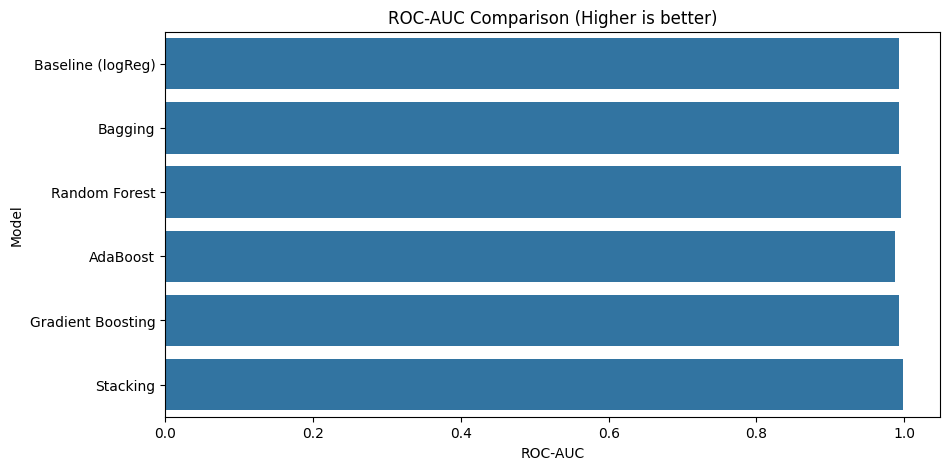

In [44]:
df=pd.DataFrame(summary)
df.sort_values(by="AUC",ascending=True)

plt.figure(figsize=(10,5))
sns.barplot(x="AUC",y="Model",data=df)
plt.xlabel("ROC-AUC")
plt.title("ROC-AUC Comparison (Higher is better)")
plt.show()

**The End**